In [15]:
from IPython.core.display import HTML
HTML("""
<style>
.consignes{
  font-weight: bold;
  color: #3256a8;
  background-color: #edebdf
}
</style>
""")



# <div class=consignes>Deep Learning et traitement du signal TP 1 </div>
<div class=consignes> L'objectif de ce TP est de prendre en main les outils de modélisation et d'analyse du signal présentés dans le premier cours et d'introduire la problématique de <it>détection</it> dont on parlera dans le cours numéro 3 </div>
<div class=consignes>Deadline : 16 octobre 2024, 13h59, par mail à deepetsignal.mva@gmail.com <br> Effort estimé : 2 à 3 heures maximum</div>
<div class=consignes>Le rendu de ce TP n'est pas obligatoire. Il permet d'obtenir un bonus de 1 (minimum syndical) à 3 (votre notebook servira de correction l'an prochain) points sur la moyenne des TP </div>

<div class=consignes> Listez les noms des étudiants (2 au maximum) ayant participé à ce notebook dans la cellule suivante (prénom, nom).<br/>
Au moment du rendu, le notebook doit être nommé nom1_nom2_dlts_tp1.ipynb </div>

Eliott Vigier


J'ai réalisé le notebook sur Colab avec les fichiers sur mon drive. Il suffit de changer les filepath des deux fichiers si vous le faites en local.

<div class=consignes>Si vous installez des paquets supplémentaires, merci de les lister dans la cellule suivante avec la syntaxe
    
```
!pip install \< nom_du_paquet \>
```
    
</div>

In [16]:
import numpy as np
import matplotlib.pylab as plt
import scipy
import IPython.display as ipd

## <div class=consignes>Partie 1: Audio </div>

### <div class=consignes>Visualisation</div>

 <div class=consignes>Enregistrez un fichier wav de quelques secondes de votre voix.
  <br>
 Importez le avec scipy.io.wavfile.read et écoutez le dans le notebook avec IPython.display.Audio
</div>

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
filepath = '/content/drive/My Drive/MVA/eliott_vigier_tp1.wav'
# Lecture du fichier wav
rate, data =  scipy.io.wavfile.read(filepath)

# Affichage des informations du fichier audio
print(f"Taux d'échantillonnage: {rate} Hz")

# Écouter le fichier audio
ipd.Audio(data, rate=rate)

Taux d'échantillonnage: 48000 Hz


<div class=consignes>Visualisez la forme d'onde temporelle de ce signal audio. <br>
Estimez et affichez sa Densité Spectrale de Puissance. <br>
Donnez une interprétation de ce que vous observez.
    </div>

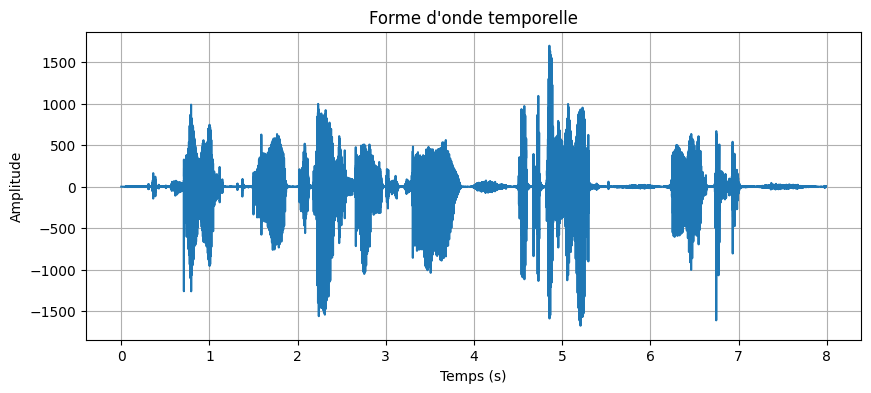

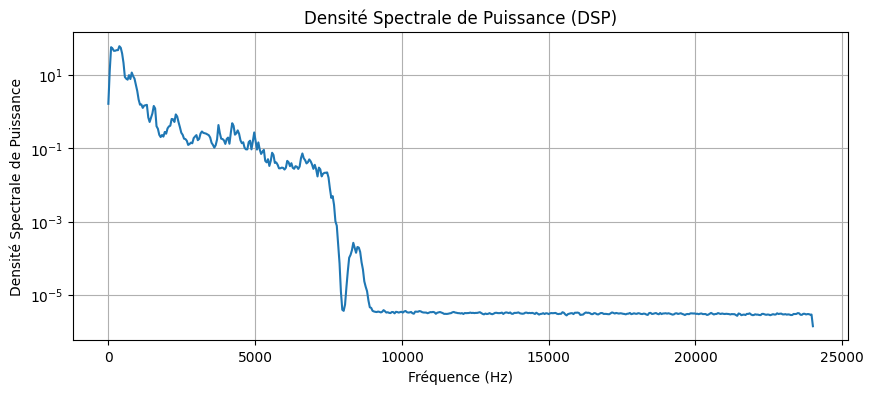

In [19]:
# Si les données sont stéréo (2 canaux), on prend un seul canal
if len(data.shape) > 1:
    data = data[:, 0]

# Affichage de la forme d'onde temporelle
time = np.linspace(0, len(data) / rate, num=len(data))

plt.figure(figsize=(10, 4))
plt.plot(time, data)
plt.title("Forme d'onde temporelle")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# Affichage de la Densité Spectrale de Puissance
frequencies, power_density = scipy.signal.welch(data, rate, nperseg=1024)

plt.figure(figsize=(10, 4))
plt.semilogy(frequencies, power_density)
plt.title("Densité Spectrale de Puissance (DSP)")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Densité Spectrale de Puissance")
plt.grid(True)
plt.show()

Le premier graphique montre la forme d'onde temporelle de ma voix, où l'amplitude fluctue dans le temps. Les sections avec de grandes amplitudes représentent les moments où ma voix est plus forte, tandis que les sections plates indiquent des pauses ou des silences.

Le second graphique représente la densité spectrale de puissance, qui montre comment l'énergie de ma voix est répartie en fonction de la fréquence. On observe que la majeure partie de l'énergie se trouve en dessous de 5000 Hz.

<div class=consignes> Calculez et affichez le spectrogramme du signal. <br>
Justifiez du choix des réglages que vous avez faits. <br>
Sélectionnez une portion pertinente du spectrogramme pour estimer visuellement le pitch de votre voix.
    </div>

J'ai choisi de couvrir l'ensemble de la durée de l'enregistrement pour le spectrogramme car, étant donné que je parle tout au long des 7 à 8 secondes, il est pertinent d'observer toutes les variations de fréquences sur cette période. Cela permet d'observer les caractéristiques de ma voix.

Pour le réglage des fréquences, j'ai limité l'affichage à 8 kHz, car c'est là que se trouvent les valeurs maximales des pics jaune-vert sur le spectrogramme. Ces pics indiquent les zones où l'énergie du signal est la plus concentrée, ce qui correspond à la partie pertinente de ma voix.

Concernant le choix du fenêtrage et du chevauchement, j'ai d'abord opté pour une fenêtre de 1024 points, ce qui me permet d'avoir une vue globale de la répartition des fréquences de ma voix sur l'ensemble de l'enregistrement. Cependant, pour estimer précisément le pitch, il vaut mieux de réduire la plage des fréquences affichées à 2000 Hz et une mettre fenêtre plus petite soit de 512 points. Cela permet de mieux visualiser la position du pic jaune le plus intense, qui représente la fréquence fondamentale de ma voix.

Même si l'énergie est concentrée entre 100 Hz et 700 Hz, le pitch correspond à la fréquence la plus basse, donc autour de 100 Hz à 200 Hz. On peut affiner la fenêtre a 256 points pour confirmer cela.

<ipython-input-20-cd1094848cf5>:10: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='gouraud')


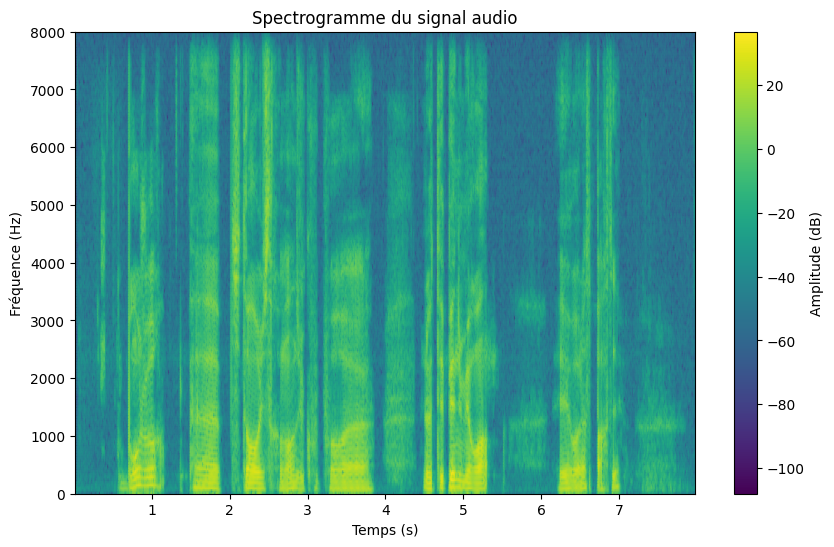

In [20]:
# Paramètres du spectrogramme
nperseg = 1024  # Longueur de la fenêtre
noverlap = nperseg // 2  # Chevauchement de 50%

# Calcul du spectrogramme
frequencies, times, Sxx = scipy.signal.spectrogram(data, rate, nperseg=nperseg, noverlap=noverlap)

# Affichage du spectrogramme
plt.figure(figsize=(10, 6))
plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='gouraud')
plt.colorbar(label='Amplitude (dB)')
plt.title("Spectrogramme du signal audio")
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence (Hz)")
plt.ylim(0, 8000)
plt.show()

<ipython-input-21-6685576d9f4a>:10: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='gouraud')


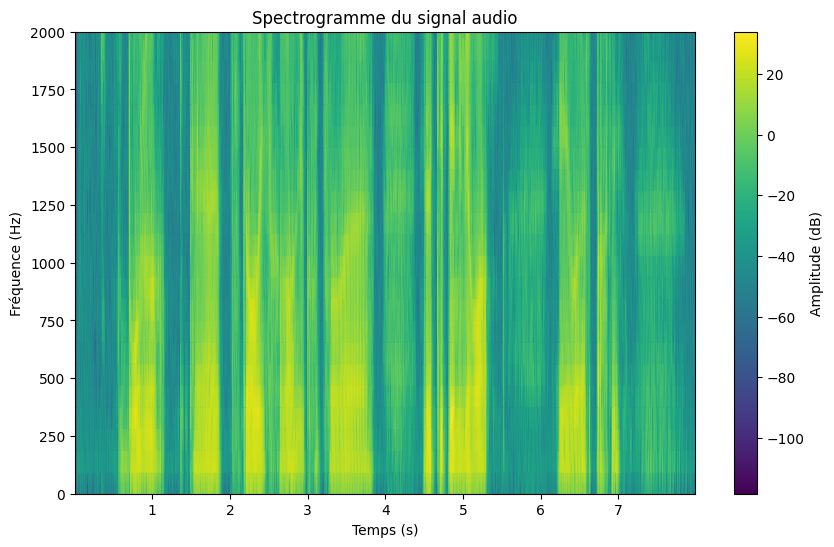

In [21]:
# Paramètres du spectrogramme
nperseg = 512  # Longueur de la fenêtre
noverlap = nperseg // 2  # Chevauchement de 50%

# Calcul du spectrogramme
frequencies, times, Sxx = scipy.signal.spectrogram(data, rate, nperseg=nperseg, noverlap=noverlap)

# Affichage du spectrogramme
plt.figure(figsize=(10, 6))
plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='gouraud')
plt.colorbar(label='Amplitude (dB)')
plt.title("Spectrogramme du signal audio")
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence (Hz)")
plt.ylim(0, 2000)
plt.show()

<ipython-input-22-8e9cae3a481b>:10: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='gouraud')


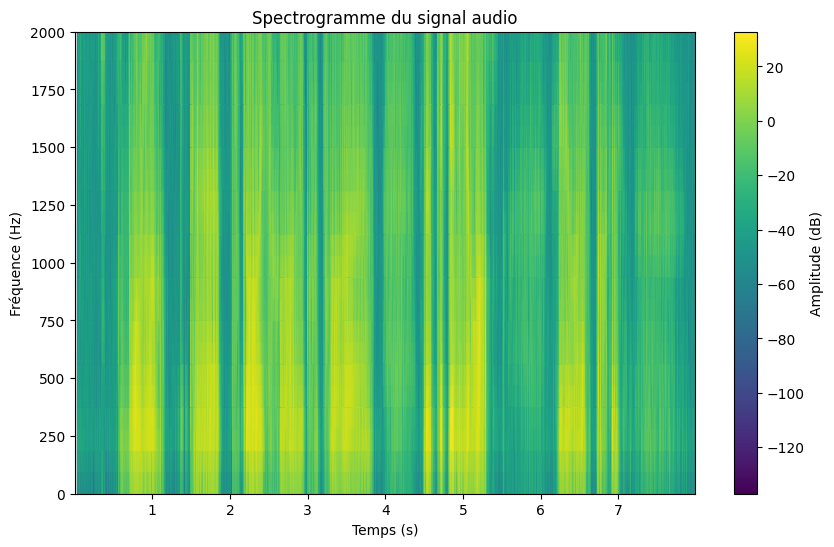

In [22]:
# Paramètres du spectrogramme
nperseg = 256  # Longueur de la fenêtre
noverlap = nperseg // 2  # Chevauchement de 50%

# Calcul du spectrogramme
frequencies, times, Sxx = scipy.signal.spectrogram(data, rate, nperseg=nperseg, noverlap=noverlap)

# Affichage du spectrogramme
plt.figure(figsize=(10, 6))
plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='gouraud')
plt.colorbar(label='Amplitude (dB)')
plt.title("Spectrogramme du signal audio")
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence (Hz)")
plt.ylim(0, 2000)
plt.show()

### <div class=consignes>Calcul du Pitch</div>

<div class=consignes>Proposez une méthode simple pour estimer automatiquement le Pitch de votre voix (cette méthode ne doit pas faire intervenir d'implémentations externes).

Utilisez cette méthode pour estimer les variations du Pitch le long du signal, estimez le pitch toutes les 20 ms et présentez vos résultats sous forme visuelle.

Ne pas utiliser de méthode "toute faite" que vous pourriez par exemple trouver dans la bibliothèque librosa.

Commentez vos résultats.
    </div>

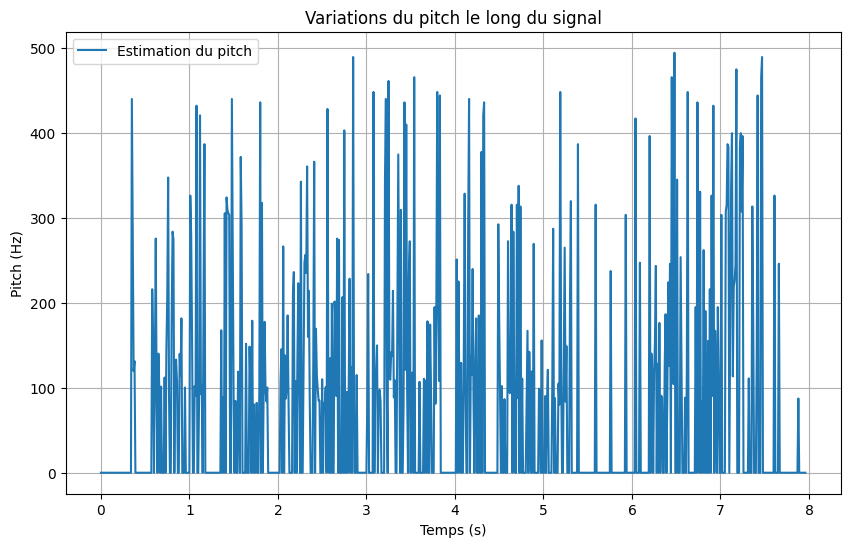

In [23]:
# Calcul de l'auto-corrélation d'un signal
def autocorrelation(x):
    result = np.correlate(x, x, mode='full')
    return result[result.size // 2:]

# Estime le pitch à partir d'un segment en utilisant l'auto-corrélation
def estimate_pitch(segment, rate):
    corr = autocorrelation(segment)
    d = np.diff(corr)

    # Vérification que 'd' contient des valeurs positives
    if np.any(d > 0):
        start = np.where(d > 0)[0][0]  # Trouver le premier maximum après le lag zéro
        peak = np.argmax(corr[start:]) + start  # Position du premier pic
        pitch = rate / peak if peak != 0 else 0
    else:
        # Si 'd' ne contient pas de valeur positive, on retourne un pitch de 0 (aucune détection)
        pitch = 0

    return pitch

# Paramètres du signal et de la méthode
frame_size = int(0.02 * rate)  # 20 ms
hop_size = frame_size // 2

pitches = []
times = []

# Découpage du signal en segments de 20 ms
for i in range(0, len(data) - frame_size, hop_size):
    segment = data[i:i + frame_size]
    pitch = estimate_pitch(segment, rate)
    pitches.append(pitch)
    times.append(i / rate)

# Filtrage des valeurs aberrantes (pitch trop bas ou trop élevé)
pitches = np.array(pitches)
pitches = np.where((pitches > 80) & (pitches < 500), pitches, 0)  # Voix humaine généralement entre 0 et 500 Hz d'après la partie précédente



# Visualisation des variations du pitch
plt.figure(figsize=(10, 6))
plt.plot(times, pitches, label='Estimation du pitch')
plt.xlabel("Temps (s)")
plt.ylabel("Pitch (Hz)")
plt.title("Variations du pitch le long du signal")
plt.grid(True)
plt.legend()
plt.show()


Le graphique montre des variations importantes du pitch de ma voix. Cela oscille entre 0 et 500 Hz. La majorité des valeurs se situent entre 100 et 300 Hz environ ce qui est cohérent pour un homme. On voit même beaucoup de valeurs entre 100 et 200 Hz. Ceci est plutôt logique commme j'ai une voix assez grave.

Cependant, il y a des fluctuations avec des pics plus élevés, probablement dus à ma manière de parler et mon intonation. A ces moments là, ma voix est donc moins monotone et penche un peu plus sur les aigus. On voit enfin aussi des moments de silences où je fais des pauses.

## <div class=consignes>Partie 2: Détection d'impulsion </div>

<div class=consignes> Un signal de durée 1 seconde et échantillonné à 1000 Hz est composé d'un bruit blanc gaussien de puissance inconnue et éventuellement d'une impulsion à une fréquence f0 comprise entre 100 et 200 Hz.
<br><br>
Une série de 1000 signaux est enregistrée dans le fichier signaux_impulsions.npz.
Ouvez ce fichier avec numpy (cf code plus bas). Le fichier contient une tableau signaux 10000 x 1000 dont chaque ligne contient un signal de durée 1000. Le fichiez contient aussi un tableau labels de taille 10000 dont la ligne i est à TRUE si le signal i contient une impulsion et à 0 sinon.

</div>

In [24]:
donnees = np.load('/content/drive/My Drive/MVA/signaux_impulsions.npz')
print(donnees.keys())
signaux = donnees['data']
labels = donnees['labels']

KeysView(NpzFile '/content/drive/My Drive/MVA/signaux_impulsions.npz' with keys: data, labels)


## <div class=consignes> Première méthode </div>

<div class=consignes> Proposez une méthode simple  pour décider si un signal contient une impulsion ou non à partir du calcul de l'énergie du signal. Cette méthode fera intervenir un seuil:
</div>

```python
def contient_impulsion_energie(signal: np.ndarray, seuil: float) -> bool:
```

J'ai choisi le seuil avec l'accuracy la plus grande. On pourra l'observer dans la dernière partie graphiquement.

In [25]:
def contient_impulsion_energie(signal: np.ndarray, seuil: float) -> bool:

    # Calcul de l'énergie du signal
    energie = np.sum(signal ** 2)

    # Comparaison avec le seuil
    return energie > seuil


##########
###TEST###
##########

# Paramètres
seuil = 99

# Definition de VP, FP, VN, FN
VP, FP, VN, FN = 0, 0, 0, 0

# # Parcourt tous les signaux et applique la méthode
for i in range(len(signaux)):
    prediction = contient_impulsion_energie(signaux[i], seuil)
    label = labels[i]

    if prediction and label:  # Vrai Positif (VP)
        VP += 1
    elif prediction and not label:  # Faux Positif (FP)
        FP += 1
    elif not prediction and not label:  # Vrai Négatif (VN)
        VN += 1
    elif not prediction and label:  # Faux Négatif (FN)
        FN += 1

# Calcul de l'accuracy
accuracy = (VP + VN) / (VP + VN + FP + FN)
# Calcul de la précision et du rappel
precision = VP / (VP + FP) if (VP + FP) > 0 else 0
recall = VP / (VP + FN) if (VP + FN) > 0 else 0

# Affichage des résultats
print(f"Vrai Positifs (VP) : {VP}")
print(f"Faux Positifs (FP) : {FP}")
print(f"Vrai Négatifs (VN) : {VN}")
print(f"Faux Négatifs (FN) : {FN}")
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Précision : {precision * 100:.2f}%")
print(f"Rappel : {recall * 100:.2f}%")

Vrai Positifs (VP) : 4639
Faux Positifs (FP) : 3236
Vrai Négatifs (VN) : 1760
Faux Négatifs (FN) : 365
Accuracy : 63.99%
Précision : 58.91%
Rappel : 92.71%


<div class=consignes>
Utilisez votre méthode avec un seuil fixé sur tous les signaux pour prédire s'ils contiennent une impulsion ou non.
</div>

<div class=consignes>
Calculez: <br>
- VP = le nombre de signaux que vous détectez comme contenant une impulsion qui contiennet effectivement une impulsion <br>
- FP = le nombre de signaux que vous détectez comme contenant une impulsion qui ne contiennet en fait PAS une impulsion <br>
- VN = le nombre de signaux que vous détectez comme ne contenant PAS une impulsion qui ne contiennet effectivement PAS une impulsion<br>
- FN = le nombre de signaux que vous détectez comme ne contenant PAS une impulsion mais qui  contiennet en fait une impulsion
</div>

## <div class=consignes>Deuxième méthode </div>

<div class=consignes>Proposez une deuxième méthode faisant par exemple intervenir le spectrogramme du signal. Cette méthode fera encore intervenir un seuil
</div>

```python
def contient_impulsion_spectrogramme(signal: np.ndarray, seuil: float) -> bool:
```


J'ai encore choisi le seuil avec l'accuracy la plus grande. On pourra l'observer dans la dernière partie graphiquement.

In [26]:
def contient_impulsion_spectrogramme(signal: np.ndarray, seuil: float) -> bool:

    # Calcul du spectrogramme
    frequencies, times, Sxx = scipy.signal.spectrogram(signal, 1000, nperseg=128)

    # Sélectionne les fréquences entre 100 Hz et 200 Hz
    idx = np.where((frequencies >= 100) & (frequencies <= 200))[0]

    # Calculer l'énergie totale dans cette bande de fréquences
    energie = np.sum(Sxx[idx, :])

    # Comparaison avec le seuil
    return energie > seuil


##########
###TEST###
##########


# Paramètres
seuil_spectrogramme = 0.09

# Definition de VP, FP, VN, FN
VP, FP, VN, FN = 0, 0, 0, 0

# Parcourt tous les signaux et applique la méthode
for i in range(len(signaux)):
    prediction = contient_impulsion_spectrogramme(signaux[i], seuil_spectrogramme)
    label = labels[i]

    if prediction and label:  # Vrai Positif (VP)
        VP += 1
    elif prediction and not label:  # Faux Positif (FP)
        FP += 1
    elif not prediction and not label:  # Vrai Négatif (VN)
        VN += 1
    elif not prediction and label:  # Faux Négatif (FN)
        FN += 1

# Calcul de l'accuracy
accuracy_spectrogramme = (VP + VN) / (VP + VN + FP + FN)

# Calcul de la précision et du rappel
precision = VP / (VP + FP) if (VP + FP) > 0 else 0
recall = VP / (VP + FN) if (VP + FN) > 0 else 0

# Affichage des résultats
print(f"Vrai Positifs (VP) : {VP}")
print(f"Faux Positifs (FP) : {FP}")
print(f"Vrai Négatifs (VN) : {VN}")
print(f"Faux Négatifs (FN) : {FN}")
print(f"Accuracy (Spectrogramme) : {accuracy_spectrogramme * 100:.2f}%")
print(f"Précision : {precision * 100:.2f}%")
print(f"Rappel : {recall * 100:.2f}%")

Vrai Positifs (VP) : 3763
Faux Positifs (FP) : 354
Vrai Négatifs (VN) : 4642
Faux Négatifs (FN) : 1241
Accuracy (Spectrogramme) : 84.05%
Précision : 91.40%
Rappel : 75.20%


<div class=consignes> Calculez pour cette nouvelle méthode, pour un certain seuil les valeurs de VP, FP, VN, FN </div>

## <div class=consignes> Comparaison des méthodes </sdivs>

<div class=consignes>Pour une méthode de détection et un seuil donné, la précision est définie comme:
$$ \frac{\sharp\text{Signaux détectés comme contenant une impulsion qui en contiennent effectivement une}}{\sharp\text{Signaux détectés comme positifs }}$$
et le rappel comme:
$$ \frac{\sharp\text{Signaux détectés comme contenant une impulsion qui en contiennent effectivement une}}{\sharp \text{Signaux contenant une impulsions}} $$
    
</div>

<div class=consignes> Donnez une interprétation de ces deux métriques </div>

La précision indique à quel point le modèle est fiable lorsqu'il signale une impulsion. Une haute précision signifie que lorsqu'une impulsion est détectée, il est très probable qu'il y en ait réellement une (peu de faux positifs). Une faible précision indique qu'il y a trop de faux positifs, ce qui signifie que le modèle détecte trop de signaux comme étant des impulsions, même s'ils n'en contiennent pas réellement.


Le rappel indique la capacité du modèle à détecter toutes les impulsions. Un rappel élevé signifie que le modèle est capable de détecter la majorité des impulsions présentes dans les signaux (peu de faux négatifs). Un rappel faible signifie que le modèle manque beaucoup d'impulsions, ce qui conduit à un grand nombre de faux négatifs.

<div class=consignes>
    Pour chacune des deux méthodes proposées, faites varier le seuil sur une dizaine de valeurs et calculez la précision et le rappel pour chacun de ces seuils.

Affichez dans le plan (précision , rappel) les points de fonctionnement des deux méthodes pour différents seuils. <br>Commentez le résultat.
    </div>

In [27]:
# Fonction pour calculer la précision, le rappel et l'accuracy en fonction de la méthode et du seuil à partir des VPs, FPs, VNs et FNs
def evaluer_modeles_seuils(signaux, labels, method, seuils):
    precisions = []
    recalls = []
    accuracies = []

    for seuil in seuils:
        VP, FP, VN, FN = 0, 0, 0, 0

        for i in range(len(signaux)):
            prediction = method(signaux[i], seuil)
            label = labels[i]

            if prediction and label:  # Vrai Positif (VP)
                VP += 1
            elif prediction and not label:  # Faux Positif (FP)
                FP += 1
            elif not prediction and not label:  # Vrai Négatif (VN)
                VN += 1
            elif not prediction and label:  # Faux Négatif (FN)
                FN += 1

        precision = VP / (VP + FP) if (VP + FP) > 0 else 0
        recall = VP / (VP + FN) if (VP + FN) > 0 else 0
        accuracy = (VP + VN) / (VP + VN + FP + FN) if (VP + VN + FP + FN) > 0 else 0

        precisions.append(precision)
        recalls.append(recall)
        accuracies.append(accuracy)

    return precisions, recalls, accuracies

# Affichage des résultats pour la précision et le rappel sur le même graphique, et accuracy sur un autre graphique
def tracer_resultats(precisions, recalls, accuracies, seuils):
    plt.figure(figsize=(12, 6))

    # Courbe de la précision et du rappel
    plt.subplot(1, 3, 1)
    plt.plot(seuils, precisions, label='Précision')
    plt.plot(seuils, recalls, label='Rappel', color='orange')
    plt.xlabel('Seuil')
    plt.ylabel('Valeur')
    plt.title('Précision et Rappel en fonction du seuil')
    plt.legend()
    plt.grid(True)

    # Courbe d'accuracy
    plt.subplot(1, 3, 2)
    plt.plot(seuils, accuracies, label='Accuracy', color='green')
    plt.xlabel('Seuil')
    plt.ylabel('Accuracy')
    plt.title('Accuracy en fonction du seuil')
    plt.grid(True)

    # Courbe précision vs rappel
    plt.subplot(1, 3, 3)
    plt.plot(recalls, precisions, label='Précision vs Rappel', color='purple')
    plt.xlabel('Rappel')
    plt.ylabel('Précision')
    plt.title('Courbe Précision vs Rappel')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Méthode 1

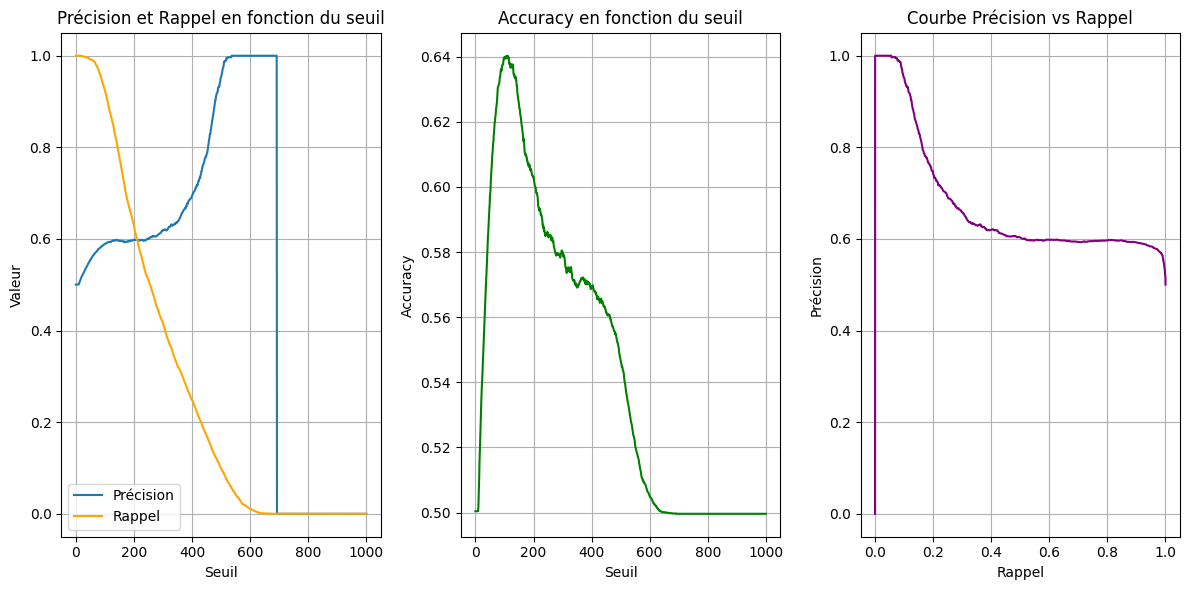

In [28]:
# Liste des seuils à tester
seuils = np.linspace(0, 1000, 1000)

# Calculs des métriques pour différents seuils
precisions, recalls, accuracies = evaluer_modeles_seuils(signaux, labels, contient_impulsion_energie, seuils)

# Affichage des résultats
tracer_resultats(precisions, recalls, accuracies, seuils)

Au début, la précision est très élevée, proche de 1, mais le rappel est très faible, ce qui signifie que le modèle est strict et ne détecte pas beaucoup d'impulsions, mais avec très peu d'erreurs (peu de faux positifs).

À mesure que le rappel augmente, la précision diminue progressivement, indiquant que le modèle détecte plus d'impulsions (rappel plus élevé) et commence à faire plus d'erreurs (faux positifs augmentent).

Vers la fin, lorsque le rappel approche de 1, la précision chute fortement, ce qui signifie que le modèle fait beaucoup de fausses détections pour détecter toutes les impulsions possibles.

Pour maximiser la détection (rappel élevé), on sacrifie la précision, et inversement.

Méthode 2

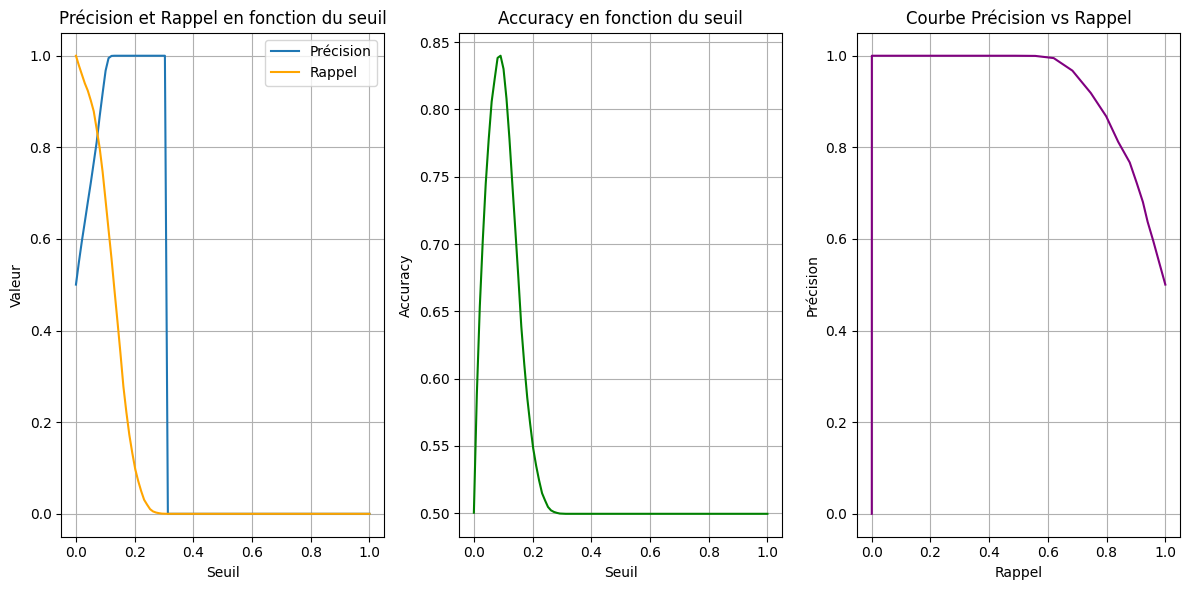

In [29]:
# Liste des seuils à tester
seuils = np.linspace(0, 1, 100)

# Calculs des métriques pour différents seuils
precisions, recalls, accuracies = evaluer_modeles_seuils(signaux, labels, contient_impulsion_spectrogramme, seuils)

# Affichage des résultats
tracer_resultats(precisions, recalls, accuracies, seuils)

 Lorsque le rappel est très faible (à gauche), la précision est maximale, ce qui indique encore une fois que le modèle est strict et ne détecte pas beaucoup d'impulsions. Cependant, ces dernières sont très précises avec peu de faux positifs.

 Au fur et à mesure que le rappel augmente, la précision commence à diminuer, signe que pour détecter plus d'impulsions (rappel plus élevé). Le modèle commence à faire des erreurs et produit plus de faux positifs.

 Vers la fin de la courbe, lorsque le rappel approche de 1, la précision chute brusquement, ce qui signifie que le modèle fait encore beaucoup de fausses détections pour détecter toutes les impulsions possibles.


 Néanmoins, on observe que la seconde méthode est bien plus stable et efficace car on observe une seule grosse chute de la précision lorsque le rappel augmente contrairement à la première méthode. Par ailleurs, cette chute est beaucoup moins rapide et plus tardive.

 La méthode 2 permet d'avoir un meilleur rappel, precision et accuracy.